# **SI 313 WN26: Final Project Progress Report**
##### Nick Pisarczyk - Monday, 04/13/26<br>uniqname: npisar<br> 
---

# **Progress Summary**
*What have you accomplished so far? / What data have you collected/analyzed?*
- I've gathered all the relevant data for my analysis
- Used a URL endpoint to grab WPRDC 311 data
- I've cleaned all the data - got rid of redundant columns, renamed columns to be nicer to work with, dropped entries with no neighborhood or census tract, matched all neighborhoods with a census tract, made tracts nice to work with by getting rid of state / city code and 
- Loaded median income from ACS data and combined it with WPRDC data
- Created a map of complaint types to make data analysis more effective - 23 categories from 247 individual types

Data Exploration
- Top 5 complaints across all the data
- Top 5 complaints / relative frequencies for each individual neighborhood
- Descriptive statistics for cleaned data
- Created 3 income "bins" to separate the wealth level of each neighborhood -- place them in an "income group"
- Relative frequency of each complaint category by income group
- Categories with the largest difference (for visualizations)

Visualizations
- Visualization 1: Heatmap of Complaint Signatures by Income Group
- Visualization 2: Grouped Bar Chart of Complaint Categories with Highest Variance by Income Group

Statistical Testing
- Kruskall-Wallis testing
- Interpretation
- Conclusion

<br><br>

*What preliminary findings do you have?*
- From testing I found that there does not appear to be a significant relationship between median income and complaint category, and therefore that 311 data cannot be used to create "complaint signatures" in smaller or medium sized cities like Pittsburgh as proposed for large cities like NYC in the Wang et al. paper.

# **Preliminary Analysis**
Include at least 2-3 figures or tables
- See below
<br><br>

Descriptive statistics of your sample
- See below
<br><br>

Initial exploration of your research question
- See below
<br><br>

# **Challenges and Solutions**
What problems have you encountered?
- I was trying to use Chi-Square for my statistical testing, but because of the way that I wanted to run my analysis by splitting up the groups (as well as due to the socioeconomic characteristics of Pittsburgh itself), the counts were leading the Chi-Square test to tell me that there are significant differences between complaint type by income group when I could see that there weren't
- Ran into problems with my analysis not being deep / impactful enough because there were so many complaint types 
<br><br>

How have you addressed them?
- I switched to using a Kruskall-Wallis test. This is used to determine if there are significant differences between two or more independent groups on a dependent variable that is ordinal or continuous, i.e. my income groups, without assuming a normal distribution like ANOVA requires. This ended up working well; instead of using all 25,000 or so complaint entries from 2024 into one table with the Chi-Square test, it looks at the data neighborhood by neighborhood, and asks if the average relative frequency of a certain complaint type differs based on whether the neighborhood is low, medium, or high income.
- I created complaint "categories" using AI. I had 247 individual complaint types, and asked AI to go through them and group similar complaint types. I got 24 categories to compare on, which is much better suited for this analysis; still broad enough to be interesting, but not so many that there's too much to look at. 

What concerns remain?
- I feel good about where I'm at right now!
<br><br>

# **Revised Plan**
What remains to be done?
- Polishing
- AI appendix
<br><br>

Updated timeline for completion
- Will finish week of the 20th when I return from traveling 
<br><br>

Any scope adjustments needed?
- No
<br><br>

---

### Project Plan / Ethics Review
https://docs.google.com/document/d/1MV13jZvPOOKMSl6CHwO51uBc4c8MzMOqv2vkrDHoB1g/edit?usp=sharing

---

# **311 Data Gathering / Cleaning**

In [ ]:
import pandas as pd
import requests
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [754]:
# helper function to preview dfs
def preview_df(df, head=False, num=20):
    print(f"{'='*50}")
    print(f"Columns:\n{df.columns.tolist()[0:]}")
    print(f"{'='*50}")
    print(f"Shape:\n{df.shape}")
    print(f"{'='*50}")
    if head:
        print(f"Data Head:\n{df.head(num)}")
        print(f"{'='*50}")

### **WPRDC 311 data from URL endpoint / save to .csv**
Grab the WPRDC 311 data from the URL endpoint

In [755]:
# # data from https://data.wprdc.org/dataset/311-data/resource/29462525-62a6-45bf-9b5e-ad2e1c06348d
# # using a SQL query to get data from just 2024

# url = (
#     "https://data.wprdc.org/api/action/datastore_search_sql"
#     "?sql=SELECT * from \"29462525-62a6-45bf-9b5e-ad2e1c06348d\" "
#     "WHERE create_date_utc >= '2024-01-01' AND create_date_utc < '2025-01-01'"
# )

# resp = requests.get(url, timeout=60)
# resp.raise_for_status()
# data = resp.json()

# if not data.get("success"):
#     raise RuntimeError(data)

# records = data["result"]["records"]
# df_long = pd.DataFrame.from_records(records)

# df_long.to_csv("data/wprdc_2024.csv", index=False)
# print(f"Wrote {len(df)} rows to wprdc_2024.csv")

### **Open the saved csv**
Instead of calling the url every time, use the saved .csv to gather data

In [756]:
csv_path = "data/wprdc_2024.csv"
df_long = pd.read_csv(csv_path)

preview_df(df_long, head=False, num=20)

Columns:
['_id', '_full_text', 'group_id', 'num_requests', 'parent_closed', 'status_name', 'status_code', 'dept', 'request_type_name', 'request_type_id', 'create_date_et', 'create_date_utc', 'last_action_et', 'last_action_utc', 'closed_date_et', 'closed_date_utc', 'origin', 'street', 'cross_street', 'street_id', 'cross_street_id', 'city', 'neighborhood', 'census_tract', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', 'geo_accuracy']
Shape:
(32000, 30)


### **311 Data Cleaning**
Get rid of redundant columns, rename columns, create new df to store this in

In [757]:
keep_cols = ["_id", "create_date_utc", "request_type_name", "census_tract", "neighborhood"]
keep_cols = [c for c in keep_cols if c in df_long.columns]

df_small = df_long.copy()
df_small = df_small.loc[:, keep_cols]

# get rid of columns we don't want
DROP_IF_PRESENT = [
    "street", "cross_street", "latitude", "longitude",
]
df_small = df_small.drop(columns=[c for c in DROP_IF_PRESENT if c in df_small.columns], errors="ignore")

# column names
rename_map = {"_id":"id", "create_date_utc":"created_date", "request_type_name":"request"}
df_small = df_small.rename(columns=rename_map)

preview_df(df_small, head=True, num=20)

Columns:
['id', 'created_date', 'request', 'census_tract', 'neighborhood']
Shape:
(32000, 5)
Data Head:
        id         created_date                   request  census_tract  \
0   796260  2024-12-05T13:07:00  Missed Recycling Pick Up  4.200308e+10   
1   784402  2024-10-01T19:45:00              Weeds/Debris           NaN   
2    61204  2024-09-01T22:52:00           Illegal Parking  4.200398e+10   
3   656756  2024-07-08T17:17:00            Rodent control  4.200318e+10   
4   625758  2024-01-11T14:18:00       Pruning (city tree)           NaN   
5   785802  2024-10-08T19:38:00              City Website           NaN   
6   800014  2024-12-17T20:06:00      Catch Basin, Clogged           NaN   
7    77784  2024-08-21T19:38:00              Weeds/Debris           NaN   
8   611835  2024-05-06T15:56:00   Litter, Public Property           NaN   
9   786247  2024-10-09T16:09:00  Missed Recycling Pick Up  4.200305e+10   
10   61211  2024-04-23T15:16:00    Curb paint application           NaN

#### **More cleaning...**

In [758]:
# Drop entries from df_small that have NO neighborhood AND no census tract
df_small = df_small.copy().dropna(subset=['neighborhood', 'census_tract'], how='all')

# load neighborhood / tract index
df_index = pd.read_csv('data/index_pittsburghneighborhoods_blocks_2020.csv')



# standardize for neighborhood / tract data bridge
df_index['tract_geoid'] = '42003' + df_index['TRACT'].astype(str).str.zfill(6)
neigh_to_tract = df_index.groupby('Neighborhood')['tract_geoid'].first().to_dict()
# print(f"Neighborhood - Tract mapping:")
# for k, v in neigh_to_tract.items():
#     print(f"    {k}: {neigh_to_tract[k]}")

# more standardization
    # converts rows with tract_geoid values into strings, or None if empty
df_small['tract_geoid'] = df_small['census_tract'].apply(lambda x: str(int(x)) if pd.notnull(x) else None)



# clean some neighborhood names
neighborhood_names_fix = {
    'Arlington': 'Arlington - Arlington Heights', 
    'Arlington Heights': 'Arlington - Arlington Heights',
    'Mount Oliver Borough': 'Mt. Oliver'
}
df_small['neighborhood_clean'] = df_small['neighborhood'].replace(neighborhood_names_fix)



# fill missing tracts using the neighborhood bridge
for index, row in df_small.iterrows():
    if pd.isna(row['tract_geoid']):
        name = row['neighborhood_clean']
        mapped_tract = neigh_to_tract.get(name)
        if mapped_tract:
            df_small.at[index, 'tract_geoid'] = mapped_tract

# avoid duplicating 311 requests by neighborhood block
# search on geoid / tract to drop any duplicates
df_index_unique = df_index[['tract_geoid', 'TRACT']].drop_duplicates(subset=['tract_geoid'])

df_joined = df_small.merge(
    df_index_unique, 
    on='tract_geoid', 
    how='inner'
)



# normalize tracts to be their normal values, not * 100 like stored in data
# convert any integers with trailing .0 into ints
df_joined['tract'] = df_joined['TRACT'] / 100
df_joined['tract'] = df_joined['tract'].apply(lambda x: f"{int(x)}" if x % 1 == 0 else f"{x}")



# final cleanup
    # flip next two lines if want full tract value not divided by 100 (for whatever reason)
df_joined = df_joined.drop(columns="TRACT")
# df_joined = df_joined.rename(columns={'TRACT': 'tract_un-normal'})
final_cols = ['id', 'created_date', 'request', 'neighborhood', 'tract']
df_joined = df_joined[final_cols]



# if needed, save the final mapped dataset
# df_joined.to_csv('data/df_joined.csv', index=False)
print(f"Successfully joined 311 data!")

Successfully joined 311 data!


### **Load ACS data and combine median income with 311 data**

In [759]:
# helper function for grabbing tracts from headers in ACS data
def extract_tract(header):
    match = re.search(r'Census Tract ([\d\.]+)', header)
    return match.group(1) if match else None

In [760]:
# load ACS data
df_acs = pd.read_csv('data/ACS-PA-5Y-2024_DP03.csv')

# need to match the "wide" ACS data with the "long" 311 data
# .melt needed because every tract is its own column in ACS.
# need all these tracts to be rows in df_explore to match with df_joined
income_row = df_acs[df_acs['Label (Grouping)'].str.contains("Median household income", na=False)]
df_income = income_row.melt(id_vars='Label (Grouping)', var_name='header', value_name='median_income')



# only grab !!Estimate columns (they actually have the data here)
df_income = df_income[df_income['header'].str.endswith('!!Estimate')].copy()
# print(f"{df_income}")

# extract the tract numbers from the header with re
# e.g. '103.01' from 'Census Tract 103.01; Allegheny County...'
df_income['tract_acs'] = df_income['header'].apply(extract_tract)

df_income['median_income'] = (
    df_income['median_income']
    .str.replace(',', '', regex=False)
    .replace('-', None)
    .astype(float)
)
# print(f"{df_income}")




# merge with df_joined
df_joined['tract'] = df_joined['tract'].astype(str)
df_income['tract_acs'] = df_income['tract_acs'].astype(str)

df_all = df_joined.merge(
    df_income[['tract_acs', 'median_income']], 
    left_on='tract', 
    right_on='tract_acs', 
    how='left'
).drop(columns=['tract_acs'])




# remove any rows with NaN in the median_income
rows_before = len(df_all)
neighborhoods_before = set(df_all['neighborhood'].unique())
# save the neighborhoods that get removed
df_missing = df_all[df_all['median_income'].isna()]
neighborhoods_with_missing = set(df_missing['neighborhood'].unique())

# create final df
df_final = df_all.dropna(subset=['median_income']).copy()

# what neighborhoods were removed entirely?
rows_after = len(df_final)
neighborhoods_after = set(df_final['neighborhood'].unique())
neighborhoods_fully_removed = neighborhoods_before - neighborhoods_after




print("--- ANALYSIS SUMMARY ---")
print(f"Total rows removed: {rows_before - rows_after}")
print(f"Neighborhoods completely removed from analysis: {list(neighborhoods_fully_removed) if neighborhoods_fully_removed else 'None'}")
print(f"Neighborhoods with at least some missing tract data: {list(neighborhoods_with_missing)}")
print(f"\n\n\n")
print(f"Successfully combined ACS and 311 data!")

--- ANALYSIS SUMMARY ---
Total rows removed: 1221
Neighborhoods completely removed from analysis: ['Chateau']
Neighborhoods with at least some missing tract data: ['Highland Park', 'Perry North', 'South Oakland', 'Squirrel Hill North', 'Bluff', 'Allegheny West', 'Point Breeze', 'Squirrel Hill South', 'Manchester', nan, 'Chateau', 'North Shore', 'Central Oakland', 'North Oakland']




Successfully combined ACS and 311 data!


### **Preview cleaned data**

In [761]:
# preview the new df
preview_df(df_final, head=True, num=20)
df_final

Columns:
['id', 'created_date', 'request', 'neighborhood', 'tract', 'median_income']
Shape:
(25153, 6)
Data Head:
        id         created_date                   request  \
0   796260  2024-12-05T13:07:00  Missed Recycling Pick Up   
1   784402  2024-10-01T19:45:00              Weeds/Debris   
3   656756  2024-07-08T17:17:00            Rodent control   
4   625758  2024-01-11T14:18:00       Pruning (city tree)   
5   800014  2024-12-17T20:06:00      Catch Basin, Clogged   
6    77784  2024-08-21T19:38:00              Weeds/Debris   
7   611835  2024-05-06T15:56:00   Litter, Public Property   
8   786247  2024-10-09T16:09:00  Missed Recycling Pick Up   
9    61211  2024-04-23T15:16:00    Curb paint application   
10  611478  2024-02-23T18:39:00                  Homeless   
11  804809  2024-12-31T02:45:00     Street Light - Repair   
12  792949  2024-11-19T23:37:00     Street Light - Repair   
13  795262  2024-11-29T20:32:00     Street Light - Repair   
14  611423  2024-04-23T18:41:00 

,id,created_date,request,neighborhood,tract,median_income
0,796260,2024-12-05T13:07:00,Missed Recycling Pick Up,Bloomfield,804,65116.0
1,784402,2024-10-01T19:45:00,Weeds/Debris,North Oakland,404,60192.0
3,656756,2024-07-08T17:17:00,Rodent control,Allentown,1803,43125.0
4,625758,2024-01-11T14:18:00,Pruning (city tree),North Oakland,404,60192.0
5,800014,2024-12-17T20:06:00,"Catch Basin, Clogged",North Oakland,404,60192.0
...,...,...,...,...,...,...
26369,733675,2024-05-08T18:40:00,Tree Removal,Homewood West,1307,31799.0
26370,733754,2024-05-06T13:26:00,Commercial Refuse/Dumpsters,East Hills,1306,32083.0
26371,814675,2024-11-05T14:46:00,Commercial Refuse/Dumpsters,Homewood North,1302,50605.0
26372,733684,2024-09-20T15:07:00,Sinkhole,Homewood North,1302,50605.0


In [762]:
# preview n/t mapping
nt_map = df_final.groupby('neighborhood')['tract'].first().to_dict()
ni_map = df_final.groupby('neighborhood')['median_income'].first().to_dict()
# print(nt_map)
# print(ni_map)

neighborhood_info = {}
for neighborhood, tract in nt_map.items():
    income = ni_map.get(neighborhood)
    neighborhood_info[neighborhood] = tract, income

i = 1
print(f"      Neighborhood  |  Tract  |  Median Income Mapping:")
for k, v in neighborhood_info.items():
    if i < 10:
        print(f"{i}     {k}: {v}")
    else:
        print(f"{i}    {k}: {v}")
    i+=1

      Neighborhood  |  Tract  |  Median Income Mapping:
1     Allegheny Center: ('5627', 60658.0)
2     Allegheny West: ('5627', 60658.0)
3     Allentown: ('1803', 43125.0)
4     Arlington: ('1608', 55761.0)
5     Arlington Heights: ('1608', 55761.0)
6     Banksville: ('2023', 75808.0)
7     Bedford Dwellings: ('509', 11986.0)
8     Beechview: ('1916', 70436.0)
9     Beltzhoover: ('5624', 41098.0)
10    Bloomfield: ('804', 65116.0)
11    Bluff: ('402', 31042.0)
12    Bon Air: ('5624', 41098.0)
13    Brighton Heights: ('2701', 75990.0)
14    Brookline: ('3206', 82537.0)
15    California-Kirkbride: ('5652', 92500.0)
16    Carrick: ('2901', 47143.0)
17    Central Business District: ('201', 82409.0)
18    Central Lawrenceville: ('901', 112885.0)
19    Central Northside: ('5651', 68845.0)
20    Central Oakland: ('405', 16721.0)
21    Crafton Heights: ('2814', 37750.0)
22    Crawford-Roberts: ('201', 82409.0)
23    Duquesne Heights: ('1911', 104286.0)
24    East Allegheny: ('2620', 38561.0)


In [763]:
# asked genAI to create some categories to more effectively analyze the data

thematic_map = {
    # Refuse & Sanitation
    'Missed Refuse Pick Up': 'Refuse & Sanitation', 'Missed Recycling Pick Up': 'Refuse & Sanitation',
    'Bulk Pick Up': 'Refuse & Sanitation', 'Special Pick Up': 'Refuse & Sanitation', 'Courtesy Pick Up': 'Refuse & Sanitation',
    'Illegal Dumping': 'Refuse & Sanitation', 'Dumping, Private Property': 'Refuse & Sanitation', 'Early Set Out': 'Refuse & Sanitation',
    'Late Set Out': 'Refuse & Sanitation', 'Litter': 'Refuse & Sanitation', 'Litter, Public Property': 'Refuse & Sanitation',
    'Weeds/Debris': 'Refuse & Sanitation', 'Recycling Violation': 'Refuse & Sanitation', 'Refuse Violations': 'Refuse & Sanitation',
    'Blue Bin Containers': 'Refuse & Sanitation', 'Dumpster': 'Refuse & Sanitation', 'Dumpster (on Street)': 'Refuse & Sanitation',
    'Commercial Refuse/Dumpsters': 'Refuse & Sanitation', 'Litter Can': 'Refuse & Sanitation', 'Litter Can, Public': 'Refuse & Sanitation',
    'Dead Animal': 'Refuse & Sanitation', 'Animal Waste': 'Refuse & Sanitation', 'Rodent control': 'Refuse & Sanitation',
    
    # Street & Infrastructure
    'Potholes': 'Street & Infrastructure', 'Paving Concern/Problem': 'Street & Infrastructure', 'Paving Request': 'Street & Infrastructure',
    'Brick or Block Repair': 'Street & Infrastructure', 'Concrete Slab Repair': 'Street & Infrastructure', 'Street Cleaning/Sweeping': 'Street & Infrastructure',
    'Landslide': 'Street & Infrastructure', 'Sinkhole': 'Street & Infrastructure', 'Bridge Maintenance': 'Street & Infrastructure',
    'Curb Cuts': 'Street & Infrastructure', 'Curb/Request for Asphalt Windrow': 'Street & Infrastructure', 'Manhole Cover': 'Street & Infrastructure',
    'Manhole Covers, PWSA': 'Street & Infrastructure', 'Utility Cut - Other': 'Street & Infrastructure', 'Utility Cut - PWSA': 'Street & Infrastructure',
    'City Cuts Concern': 'Street & Infrastructure', 'Sidewalk/Curb/ADA Ramp Maintenance': 'Street & Infrastructure', 'Broken Sidewalk': 'Street & Infrastructure',
    'Repair City Steps': 'Street & Infrastructure',
    
    # Transportation & Parking
    'Illegal Parking': 'Transportation & Parking', 'Abandoned Vehicle (parked on street)': 'Transportation & Parking',
    'Towed Vehicle': 'Transportation & Parking', 'Junk Vehicles (Private Property)': 'Transportation & Parking', 'Speeding': 'Transportation & Parking',
    'Traffic Enforcement': 'Transportation & Parking', 'Traffic Calming': 'Transportation & Parking', 'Loading Zone, Request': 'Transportation & Parking',
    'Permit Parking (Request for RPP zone)': 'Transportation & Parking', 'Parking Authority': 'Transportation & Parking', 'Ticket, Pgh Parking Authority': 'Transportation & Parking',
    'Ticket, Police-issued': 'Transportation & Parking', 'SPIN (Stand Up) Scooters': 'Transportation & Parking', 'Boat/Trailer on Street': 'Transportation & Parking',
    
    # Water & Sewage
    'Catch Basin, Clogged': 'Water & Sewage', 'Collapsed Catch Basin': 'Water & Sewage', 'Water Main Break': 'Water & Sewage', 
    'Leak': 'Water & Sewage', 'Drainage/Leak': 'Water & Sewage', 'Flooding': 'Water & Sewage', 'Sewage': 'Water & Sewage', 
    'Sewers': 'Water & Sewage', 'Stormwater Runoff': 'Water & Sewage', 'Water Pressure': 'Water & Sewage', 'No Water': 'Water & Sewage',
    
    # Building & Property
    'Building Maintenance': 'Building & Property Standards', 'Building Without a Permit': 'Building & Property Standards', 'Vacant Building': 'Building & Property Standards', 
    'Vacant Lot': 'Building & Property Standards', 'Board Up (City-owned property only)': 'Building & Property Standards', 'Fence Maintenance': 'Building & Property Standards', 
    'Zoning Issue': 'Building & Property Standards', 'Overgrowth': 'Building & Property Standards', 'Couch on Porch': 'Building & Property Standards', 
    'Unpermitted Electrical Work': 'Building & Property Standards', 'Unpermitted Fire System Work': 'Building & Property Standards',
    
    # Noise & Nuisance
    'Noise': 'Noise & Nuisance', 'Excessive Noise/Disturbances': 'Noise & Nuisance', 'Nuisance Bar': 'Noise & Nuisance', 
    'Barking Dog': 'Noise & Nuisance', 'Panhandling': 'Noise & Nuisance',
    
    # Parks & Greenery
    'Pruning (city tree)': 'Parks & Greenery', 'Tree Removal': 'Parks & Greenery', 'Tree Issues': 'Parks & Greenery', 
    'Stump Grind/Removal': 'Parks & Greenery', 'Root prune': 'Parks & Greenery', 'Dead tree (Public property)': 'Parks & Greenery', 
    'Tree Fallen Across Road': 'Parks & Greenery', 'Playground': 'Parks & Greenery', 'Ballfield': 'Parks & Greenery', 
    'Park Shelter': 'Parks & Greenery', 'Overgrowth, Parks': 'Parks & Greenery', 'Dead Tree (3TB)': 'Parks & Greenery', 'Tree Fallen Across Sidewalk': 'Parks & Greenery',
    
    # Safety & Lighting
    'Street Light - Repair': 'Safety & Lighting', 'Street Light - Request': 'Safety & Lighting', 'Lights': 'Safety & Lighting', 
    'Drug Enforcement': 'Safety & Lighting', 'Gang Activity': 'Safety & Lighting', 'Police - Submit a Tip': 'Safety & Lighting', 
    'Fire Safety System Issue': 'Safety & Lighting', 'Wires': 'Safety & Lighting',

    # Snow & Ice Removal
    'Snow/Ice removal': 'Snow & Ice Removal', 'Sidewalk, Lack of Snow/Ice Removal': 'Snow & Ice Removal', 
    'Sidewalk has Ice or Litter': 'Snow & Ice Removal', 'City Steps, Need Cleared': 'Snow & Ice Removal', 
    'Salt Box': 'Snow & Ice Removal', 'Snow Angel Concern': 'Snow & Ice Removal',
    
    # Traffic Signals & Signs
    'Replace/Repair a Sign': 'Traffic Signals & Signs', 'Traffic or Pedestrian Signal, Repair': 'Traffic Signals & Signs', 
    'Request New Sign': 'Traffic Signals & Signs', 'Traffic Shop': 'Traffic Signals & Signs', 
    'Traffic Signal Request': 'Traffic Signals & Signs', 'Traffic or Pedestrian Signal, Request': 'Traffic Signals & Signs', 
    'Pedestrian Signal Maintenance': 'Traffic Signals & Signs', 'Signs, Advertising or Political': 'Traffic Signals & Signs', 
    'Sign': 'Traffic Signals & Signs', 'Traffic Signals Surtrac': 'Traffic Signals & Signs', 'Pedestrian Signal Request': 'Traffic Signals & Signs',
    
    # Active Transportation (Bike/Ped)
    'Bicycle/Pedestrian Concerns': 'Active Transportation', 'Bike Lane Bollard': 'Active Transportation', 
    'Blocked or Closed Sidewalks': 'Active Transportation', 'Blocked or Closed Trails': 'Active Transportation', 
    'Trail Maintenance': 'Active Transportation', 'Bicycle Parking': 'Active Transportation', 
    'Crosswalk and Street Markings, Maintenance': 'Active Transportation', 'Crosswalk, New': 'Active Transportation', 
    'Pavement Marking, New': 'Active Transportation',
    
    # Traffic Safety & Crashes
    'Dashcam': 'Traffic Safety & Crashes', 'Crashes and Close Calls': 'Traffic Safety & Crashes', 
    'Traffic Improvement': 'Traffic Safety & Crashes', 'Barricades': 'Traffic Safety & Crashes', 'Crossing Guards': 'Traffic Safety & Crashes',
    
    # Right of Way & Obstructions
    'Street Obstruction/Closure': 'Right of Way & Obstructions', 'Road': 'Right of Way & Obstructions', 
    'Public Right of Way': 'Right of Way & Obstructions', 'ROW': 'Right of Way & Obstructions', 
    'Construction Site Maintenance': 'Right of Way & Obstructions', 'Guide Rail': 'Right of Way & Obstructions', 'Angle Iron': 'Right of Way & Obstructions',
    
    # City Property Maintenance
    'City Owned Property Maintenance': 'City Property Maintenance', 'City Facility': 'City Property Maintenance', 
    'Water/Drinking Fountains': 'City Property Maintenance', 'Bus Shelter': 'City Property Maintenance', 
    'Bus Stop Request': 'City Property Maintenance', 'PRT': 'City Property Maintenance', 'County Maintenance': 'City Property Maintenance', 
    'URA property': 'City Property Maintenance', 'Land Bank': 'City Property Maintenance', 'Shelters': 'City Property Maintenance', 
    'Port A Potty': 'City Property Maintenance',
    
    # Accessibility (ADA)
    'Americans with Disabilities': 'Accessibility (ADA)', 'Accessible Parking Signs, Removal': 'Accessibility (ADA)', 
    'Business Accessibility': 'Accessibility (ADA)', 'Accessibility Construction Issue': 'Accessibility (ADA)', 
    'Accessible Parking Application': 'Accessibility (ADA)', 'ADA Ramp, Installation': 'Accessibility (ADA)',
    
    # Graffiti & Vandalism
    'Graffiti in Right of Way': 'Graffiti & Vandalism', 'Graffiti on Structure': 'Graffiti & Vandalism',
    
    # Homelessness
    'Homeless': 'Homelessness',
    
    # Govt. Accountability & Ethics
    'Misconduct/City Employee': 'Govt Accountability', '911 Performance': 'Govt Accountability', 
    'Ethics Office': 'Govt Accountability', 'Commission on Human Relations': 'Govt Accountability', 'MO Escalated': 'Govt Accountability',
    
    # Property & Business Compliance
    'Operating Without a License': 'Property & Business Compliance', 'Tenant/Landlord Problems': 'Property & Business Compliance', 
    'Electrical Violation': 'Property & Business Compliance', 'HVAC Not Functioning': 'Property & Business Compliance', 
    'Plastic Bag Ban Compliance': 'Property & Business Compliance', 'Unpermitted Land Operations': 'Property & Business Compliance', 
    'Building Benchmark Ordinance': 'Property & Business Compliance', 'Improper Work in a Historic District': 'Property & Business Compliance', 
    'Food Safety Complaints': 'Property & Business Compliance', 'Paid Sick Leave': 'Property & Business Compliance', 
    'Unpermitted HVAC Work': 'Property & Business Compliance', 'Unpermitted Sign Construction': 'Property & Business Compliance',
    
    # Tax & Financial Admin
    'Real Estate Tax': 'Tax & Financial Admin', 'Earned Income Tax': 'Tax & Financial Admin', 
    'Homestead Act/Senior Tax Relief': 'Tax & Financial Admin', 'EMS Billing': 'Tax & Financial Admin', 'PWSA Billing or Shut Off': 'Tax & Financial Admin',
    
    # Animals & Wildlife
    'Loose Dog(s)': 'Animals & Wildlife', 'Deer Management Pilot Program': 'Animals & Wildlife', 
    'Dog License': 'Animals & Wildlife', 'Off Leash Exercise Area': 'Animals & Wildlife',
    
    # Parks & Rec (Facilities)
    'Field': 'Parks & Rec (Facilities)', 'Parks Trails': 'Parks & Rec (Facilities)', 'Court, Basketball or Tennis': 'Parks & Rec (Facilities)', 
    'Park Ranger': 'Parks & Rec (Facilities)', 'Greenways': 'Parks & Rec (Facilities)', 'Basketball Hoop': 'Parks & Rec (Facilities)',
    
    # Utilities & Weather Impact
    'Storm Damage': 'Utilities & Weather Impact', 'Hydrant': 'Utilities & Weather Impact', 'Utility Pole': 'Utilities & Weather Impact', 
    'Leaves/Street Cleaning': 'Utilities & Weather Impact', 'Leaves, Grass or Other Yard Debris': 'Utilities & Weather Impact'
}

# Apply the mapping. Anything not in this dictionary gets mapped to "Uncategorized/Other"
df_remapped = df_final.copy()
df_remapped['request_category'] = df_remapped['request'].map(thematic_map).fillna('Uncategorized/Other')

# See how few are left uncategorized
print(df_remapped['request_category'].value_counts())

request_category
Refuse & Sanitation               8144
Street & Infrastructure           2863
Transportation & Parking          1998
Safety & Lighting                 1633
Traffic Signals & Signs           1245
Building & Property Standards     1179
Snow & Ice Removal                1006
Parks & Greenery                   982
Traffic Safety & Crashes           882
Active Transportation              776
Uncategorized/Other                690
City Property Maintenance          605
Water & Sewage                     520
Right of Way & Obstructions        463
Noise & Nuisance                   408
Utilities & Weather Impact         313
Homelessness                       302
Govt Accountability                266
Accessibility (ADA)                215
Property & Business Compliance     215
Graffiti & Vandalism               172
Parks & Rec (Facilities)           162
Tax & Financial Admin               67
Animals & Wildlife                  47
Name: count, dtype: int64


---

# **Data Exploration**

### **5 most common complaint types across all data**

In [764]:
df_explore = df_remapped.copy()

# define the top 5
top5_overall = df_explore['request_category'].value_counts().head(5).reset_index()
top5_overall.columns = ['Complaint Type', 'Total Count']

total_complaints = df_explore.shape[0]
total_neighborhoods = df_explore['neighborhood'].nunique()
print(f"Total complaints: {total_complaints}")
print(f"Total neighborhoods: {total_neighborhoods}")

print(f"\n--- Table 1: Top 5 Most Common Complaints Overall ---")
top5_overall

Total complaints: 25153
Total neighborhoods: 87

--- Table 1: Top 5 Most Common Complaints Overall ---


,Complaint Type,Total Count
0,Refuse & Sanitation,8144
1,Street & Infrastructure,2863
2,Transportation & Parking,1998
3,Safety & Lighting,1633
4,Traffic Signals & Signs,1245


### **5 most common complaint categories in every individual neighborhood**

In [765]:
neighborhood_counts = (
    df_explore.groupby('neighborhood')['request_category']
    .value_counts(normalize=True)
    .reset_index(name='relative_frequency')
)

# converted to percentage for readability
neighborhood_counts['percentage'] = (neighborhood_counts['relative_frequency'] * 100).round(2)

# select top 5 for each neighborhood
top5_neighborhood = (
    neighborhood_counts.groupby('neighborhood')
    .head(5)
    .reset_index(drop=True)
)

print(f"--- Table 2: Top 5 Complaints per Neighborhood ---")
top5_neighborhood

--- Table 2: Top 5 Complaints per Neighborhood ---


,neighborhood,request_category,relative_frequency,percentage
0,Allegheny Center,Snow & Ice Removal,0.184834,18.48
1,Allegheny Center,Safety & Lighting,0.174171,17.42
2,Allegheny Center,Traffic Safety & Crashes,0.150474,15.05
3,Allegheny Center,Street & Infrastructure,0.116114,11.61
4,Allegheny Center,Active Transportation,0.071090,7.11
...,...,...,...,...
377,Westwood,Water & Sewage,0.500000,50.00
378,Westwood,Homelessness,0.250000,25.00
379,Westwood,Safety & Lighting,0.250000,25.00
380,Windgap,Refuse & Sanitation,0.500000,50.00


### **Summary / Descriptive Stats**

In [766]:
summary_stats = {
    "Total Requests": len(df_explore),
    "Unique Neighborhoods": df_explore['neighborhood'].nunique(),
    "Unique Request Types": df_explore['request'].nunique(),
    "Descriptive Stats": df_explore['median_income'].describe()
}

print("\n--- Summary Statistics ---")
for k, v in summary_stats.items():
    if k == "Descriptive Stats":
        print(f"\n{k}:\n{v}")
    else:
        print(f"{k}: {v}")


--- Summary Statistics ---
Total Requests: 25153
Unique Neighborhoods: 87
Unique Request Types: 247

Descriptive Stats:
count     25153.000000
mean      72420.996303
std       36713.688650
min        8889.000000
25%       52099.000000
50%       68708.000000
75%       83500.000000
max      222778.000000
Name: median_income, dtype: float64


### **Income "Bin" Separation - Low / Medium / High Income Groups**

In [767]:
# Place each in an "income group"
# This is based on the quartiles above ^^ 0.00-0.50, 0.50-0.75, 0.75-1.00
    # 68k seemed like a decent cutoff point for "Low Income: based on research and the other quartiles
df_explore['income_group'] = pd.qcut(df_explore['median_income'], q=[0, 0.5, 0.75, 1], labels=["Low Income", "Medium Income", "High Income"])

# Compare top 3 complaint types across income groups
income_signature = (
    df_explore.groupby('income_group', observed=False)['request_category']
    .value_counts(normalize=True)
    .groupby(level=0, observed=False)
    .head(5)
    .reset_index(name='relative_freq')
)

print("\n--- Complaint Signatures by Income Group ---")
income_signature


--- Complaint Signatures by Income Group ---


,income_group,request_category,relative_freq
0,Low Income,Refuse & Sanitation,0.386511
1,Low Income,Street & Infrastructure,0.102300
2,Low Income,Transportation & Parking,0.071969
3,Low Income,Safety & Lighting,0.065653
4,Low Income,Building & Property Standards,0.056686
5,Medium Income,Refuse & Sanitation,0.261577
6,Medium Income,Street & Infrastructure,0.110763
7,Medium Income,Transportation & Parking,0.079631
8,Medium Income,Safety & Lighting,0.063830
9,Medium Income,Traffic Signals & Signs,0.058041


### **Relative frequency of each complaint category by income group**

In [768]:
# normalize='index' to make sure all groups sum to 100%
category_freq = pd.crosstab(
    df_explore['income_group'], 
    df_explore['request_category'], 
    normalize='index'
) * 100

##### **Categories with the largest difference (for visualizations)**

In [769]:
# Standard deviation measures how spread out the percentages are from their average across all 3 groups
category_std = category_freq.std(axis=0)

# Select the 5 categories with the highest standard deviation
top5_std = category_std.nlargest(5).index

# Filter the frequency table to just these 5 categories and melt it for plotting
freq_top5_std = category_freq[top5_std].reset_index()
freq_top5_std_melted = freq_top5_std.melt(id_vars='income_group', var_name='request_category', value_name='percentage')
print(f"Top 5 Most Different Variables\n{freq_top5_std_melted}")

Top 5 Most Different Variables
     income_group         request_category  percentage
0      Low Income      Refuse & Sanitation   38.651072
1   Medium Income      Refuse & Sanitation   26.157697
2     High Income      Refuse & Sanitation   25.522237
3      Low Income  Street & Infrastructure   10.230019
4   Medium Income  Street & Infrastructure   11.076345
5     High Income  Street & Infrastructure   14.201482
6      Low Income         Parks & Greenery    3.235867
7   Medium Income         Parks & Greenery    3.191489
8     High Income         Parks & Greenery    6.115229
9      Low Income    Active Transportation    1.996101
10  Medium Income    Active Transportation    4.974969
11    High Income    Active Transportation    3.402965
12     Low Income       Snow & Ice Removal    4.701754
13  Medium Income       Snow & Ice Removal    4.411765
14    High Income       Snow & Ice Removal    2.038410


# **Visualizations**

In [770]:
# theme
sns.set_theme(style="whitegrid")

### **Visualization 1: Heatmap of Complaint Signatures by Income Group**

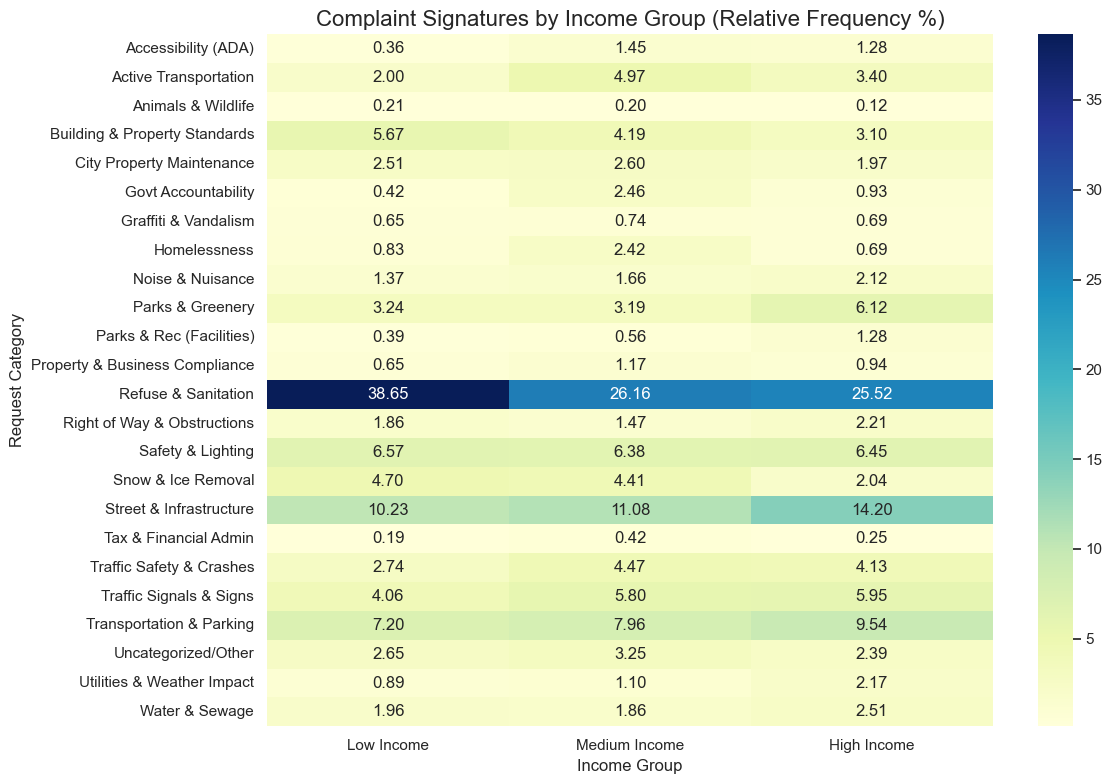

In [771]:
plt.figure(figsize=(12, 8))
sns.heatmap(category_freq.T, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Complaint Signatures by Income Group (Relative Frequency %)", fontsize=16)
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Request Category", fontsize=12)
plt.tight_layout()
plt.show()

### **Visualization 2: Grouped Bar Chart of Complaint Categories with Highest Variance by Income Group**

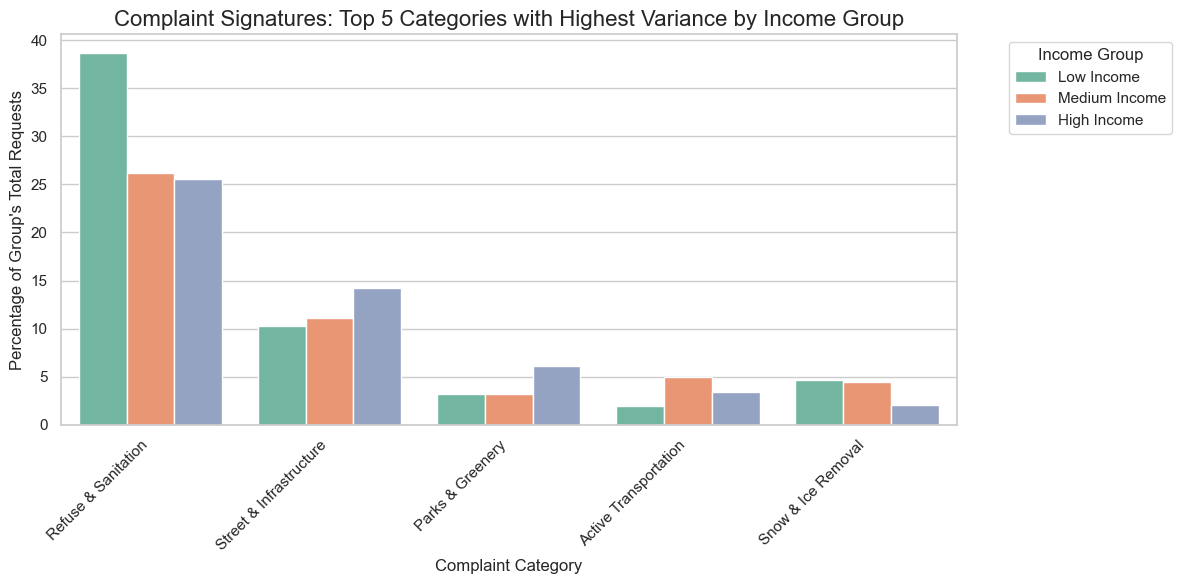

--- Top 5 Categories by Standard Deviation ---
request_category
Refuse & Sanitation         7.4 std dev
Street & Infrastructure    2.09 std dev
Parks & Greenery           1.68 std dev
Active Transportation      1.49 std dev
Snow & Ice Removal         1.46 std dev
dtype: object


In [772]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=freq_top5_std_melted, 
    x='request_category', 
    y='percentage', 
    hue='income_group', 
    palette="Set2"
)
plt.title("Complaint Signatures: Top 5 Categories with Highest Variance by Income Group", fontsize=16)
plt.xlabel("Complaint Category", fontsize=12)
plt.ylabel("Percentage of Group's Total Requests", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

# Print the standard deviations
print("--- Top 5 Categories by Standard Deviation ---")
print(category_std.nlargest(5).round(2).astype(str) + " std dev")

---

# **Statistical Testing: Kruskall-Wallis**

### **Why Kruskall-Wallis?**
This is a more advanced test that we didn't talk about much in class, so some justification: I was originally using a Chi-Square test, but I was getting strange results that weren't matching the visualizations and my intuition, since that was comparing observed vs expected counts, not relative frequencies. I needed to switch to an ANOVA test to test for a difference between groups... but I knew that I didn't have a normal distribution.<br><br>
That's where Kruskall-Wallis comes in. It's used to determine if there are significant differences between two or more independent groups on a dependent variable that is ordinal or continuous, i.e. my income groups, without assuming a normal distribution like ANOVA requires. This ended up working well; instead of using all 25,000 or so complaint entries from 2024 into one table with the Chi-Square test, it looks at the data neighborhood by neighborhood, and asks if the average relative frequency of a certain complaint type differs based on whether the neighborhood is low, medium, or high income.

In [773]:
# calculate percentages
    # count of each type divided by total number of requests
neigh_counts = df_explore.groupby(['neighborhood', 'income_group', 'request_category'], observed=True).size().reset_index(name='count')
neigh_totals = neigh_counts.groupby('neighborhood')['count'].transform('sum')
neigh_counts['percentage'] = (neigh_counts['count'] / neigh_totals) * 100
all_variable_cats = category_std.index


print("--- Kruskal-Wallis Testing ---\n")
top5_overall_list = top5_overall['Complaint Type'].unique()
top5_std_list = freq_top5_std_melted['request_category'].unique()
# print(top5_overall_list)
# print(top5_std_list)
count_sig = 0
top5_overall_sig = []
top5_std_sig = []

for category in all_variable_cats:
    cat_data = neigh_counts[neigh_counts['request_category'] == category]
    
    # Split the percentages into lists based on income group
    low = cat_data[cat_data['income_group'] == 'Low Income']['percentage']
    med = cat_data[cat_data['income_group'] == 'Medium Income']['percentage']
    high = cat_data[cat_data['income_group'] == 'High Income']['percentage']
    
    # Run the Kruskal-Wallis test - percentages not normally distributed like ANOVA requires
    stat, p_val = stats.kruskal(low, med, high)
    
    print(f"Category: {category}")
    print(f"  Kruskal-Wallis Statistic: {stat:.2f}")
    print(f"  P-Value: {p_val:.4f}")
    
    if p_val > 0.05:
        print("  Conclusion: NO significant relationship. (Frequencies are similar across income groups)")
    else:
        print("  Conclusion: SIGNIFICANT relationship found. (Frequencies differ by income group)")
        if category in top5_overall_list:
            top5_overall_sig.append(category)
        if category in top5_std_sig:
            top5_std_sig.append(category)
        count_sig += 1
    print("-" * 60)

print(f"\n{count_sig}/{len(all_variable_cats)} Significant")


print(f"\n\n\nSignificant Results:\nTop 5 Overall Complaints | which are significant:\n    {top5_overall_list}\n    {top5_overall_sig}\n{len(top5_overall_sig)} of 5 significant")
print(f"\nTop 5 Complaints with Highest STD | which are significant:\n    {top5_std_list}\n    {top5_std_sig}\n{len(top5_std_sig)} of 5 significant")

--- Kruskal-Wallis Testing ---

Category: Accessibility (ADA)
  Kruskal-Wallis Statistic: 0.16
  P-Value: 0.9238
  Conclusion: NO significant relationship. (Frequencies are similar across income groups)
------------------------------------------------------------
Category: Active Transportation
  Kruskal-Wallis Statistic: 4.31
  P-Value: 0.1159
  Conclusion: NO significant relationship. (Frequencies are similar across income groups)
------------------------------------------------------------
Category: Animals & Wildlife
  Kruskal-Wallis Statistic: 1.07
  P-Value: 0.5865
  Conclusion: NO significant relationship. (Frequencies are similar across income groups)
------------------------------------------------------------
Category: Building & Property Standards
  Kruskal-Wallis Statistic: 7.60
  P-Value: 0.0224
  Conclusion: SIGNIFICANT relationship found. (Frequencies differ by income group)
------------------------------------------------------------
Category: City Property Maintenance


### **Interpretation of Kruskall-Wallis Results**

A series of Kruskal-Wallis tests were run to determine if the relative frequencies of 24 distinct 311 complaint categories differed significantly across Pittsburgh neighborhoods based on income group (low, medium, and high income). <br>

The tests revealed a statistically significant difference ($p < .005$) in the relative frequency of 6 complaint categories. Of the five most common complaint categories across Pittsburgh, *Refuse & Sanitation* ($\chi^2(2) = 14.86, p < .001$) and *Transportation & Parking* ($\chi^2(2) = 6.90, p < .005$) were the only categories with results considered statistically significant. However, no statistically significant differences were found across income groups for the other major complaint categories in the city.<br>

The relative frequencies of complaints remained relatively consistent regardless of income group for *Street & Infrastructure* ($\chi^2(2) = 0.51, p = .775$), *Parks & Greenery* ($\chi^2(2) = 0.44, p = .803$), *Active Transportation* ($\chi^2(2) = 4.31, p = .116$), and *Snow & Ice Removal* ($\chi^2(2) = 1.84, p = .399$), *Traffic Signals & Signs* ($\chi^2(2) = 2.57, p = .2769$), and *Safety & Lighting* ($\chi^2(2) = 0.79, p = .6740$). These six complaint types are found in one or both of the top five most common complaint categories across Pittsburgh or the five categories with the largest standard variation (the most "varied" categories).<br>

These findings reveal that most common complaint types like infrastructure maintenance, parks, snow removal, signs, and safety concerns are universally reported across the city of Pittsburgh, regardless of median income level. While refuse and sanitation and transportation in parking do seem to differ by median income level, they don't offer enough evidence to suggest that 311 data in Pittsburgh can produce distinct academic "signatures" like it can in New York

---

# **Conclusion**

Unlike the findings of Wang et al. for larger cities like NYC, multiple table figures, visualizations, and a Kruskal-Wallis analysis of Pittsburgh's 311 data at the neighborhood level showed no statistically significant relationship between median income and the relative frequency of major complaint types (p > 0.05). This suggests that in a mid-sized city like Pittsburgh, core issues like refuse, infrastructure, and parking are reported regardless of neighborhood wealth, and therefore cannot produce distinct socioeconomic 'complaint signatures' like Wang et al. found in large cities like NYC.

---

# **AI Appendix**

asdasdasd